#### Preprocessing code

Code to convert MATLAB processing into Python

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

#### Import packages


In [1]:
from __future__ import annotations
import os
from pathlib import Path
from datetime import datetime
from typing import List, Any, Dict
import numpy as np
import pandas as pd
import psutil
from functools import partial
from joblib import Parallel, delayed 
import notebook_setup
info = notebook_setup.setup()
# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
from concurrent.futures import ProcessPoolExecutor, as_completed

Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


In [2]:
#import local yaml for env preset variables
from analysis_config_loader import load_analysis_config  # new import
config_path = "analysis_config.yaml"  # adjust as needed
analysis_config = load_analysis_config(config_path)

In [3]:
type(analysis_config)
analysis_config
stage_names = analysis_config.task_phase_names
stage_cols =  stage_names
stage_names


['Early_IA_Error',
 'Early_IA_Correct',
 'Late_IA',
 'Early_RS_Error',
 'Early_RS_Correct',
 'Late_RS']

#### Define dataset methods

In [101]:
#set parameters
data_types = ['spikes', 'dff']
data_type_used = data_types[1] #OR, 'dff'
run_activity_enrichment = True

# set up locations for input/output #get where to load data 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
os.chdir(root_dir)
data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')

#source dataset location has files created 10-26-2024
source_dataset_location = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19")
hour_str = datetime.now().strftime("%H")



In [48]:
## Matlab file handling functions:
import h5py

def check_corrupted_files(failed_files):
    # Optional Investigate corrupted files

    if len(failed_files) == 0:
        print("No failed files to investigate.")
        return
    
    for fname in failed_files:
        filepath = source_dataset_location / fname
        
        print(f"\n📁 {fname}")
        print("-" * 70)
        
        if not filepath.exists():
            print("   File does not exist!")
            continue
        
        # Check file size
        size_bytes = filepath.stat().st_size
        size_kb = size_bytes / 1024
        size_mb = size_kb / 1024
        
        print(f"  Size: {size_bytes:,} bytes ({size_mb:.2f} MB)")
        
        # Read first bytes to check file signature
        with open(filepath, 'rb') as f:
            header = f.read(100)
        
        # Check for MATLAB file signatures
        print(f"  First 20 bytes (hex): {header[:20].hex()}")
        
        # HDF5 files should start with \x89HDF\r\n\x1a\n
        if header[:4] == b'\x89HDF':
            print("  ✓ Valid HDF5 signature")
        elif header[:4] == b'MATL':
            print("  ⚠️ Old MATLAB format (v5/v6) - needs scipy.io")
        else:
            print(f"   Unknown file signature - file may be corrupted")
            print(f"     Expected: b'\\x89HDF' or b'MATL'")
            print(f"     Got: {header[:4]}")
        
        # Try to detect if file is truncated
        if size_mb < 1:
            print(f"  ⚠️ WARNING: File is unusually small ({size_mb:.2f} MB)")

    # Compare with a working file
    print("\n" + "="*70)
    print("COMPARISON WITH WORKING FILES:")

    # Get file sizes of all working files
    working_sizes = []
    for obj in loaded_objects[:5]:
        fname = obj['name'] + '_dataset_object.mat'
        fpath = source_dataset_location / fname
        if fpath.exists():
            size_mb = fpath.stat().st_size / 1024 / 1024
            working_sizes.append(size_mb)
            print(f"  {fname}: {size_mb:.2f} MB")

    if working_sizes:
        avg_size = sum(working_sizes) / len(working_sizes)
        print(f"\n  Average working file size: {avg_size:.2f} MB")

def load_matlab_object(filepath):
    """Load MATLAB dataset_with_spatial_ROI object from .mat file"""
    # Parse metadata from filename
    filename = filepath.stem.replace('_dataset_object', '')
    parts = filename.split('_')
    
    # Extract name, geno from filename (e.g., "10_3_HET_RS1")
    name = filename
    if len(parts) >= 3:
        geno = parts[2]  # HET or WT
        session = parts[3] if len(parts) > 3 else 'RS1'
    else:
        geno = "UNKNOWN"
        session = "RS1"
    
    try:
        with h5py.File(filepath, 'r') as f:            # Load numeric data from known datasets
            raster = f['#refs#']['i'][()]  # (time, cells)
            # Get deduplicated flag from group x
            deduplicated = f['#refs#']['x']['deduplicated'][0, 0] if 'deduplicated' in f['#refs#']['x'] else False
            # Create object dictionary
            obj = {
                'name': name,
                'geno': geno,
                'session': session,
                'geno_day': None,  # Will need to be set externally if needed
                'raster': raster,  # DON"T  Transpose to (cells, time), as df transposes later
                'deduplicated': bool(deduplicated),
                'good_cells': f['#refs#']['k'][()] if 'k' in f['#refs#'] else None,  # Cell IDs
                'labels': f['#refs#']['j'][()] if 'j' in f['#refs#'] else None,  # Trial/time info
                'dff': f['#refs#']['p'][()] if 'p' in f['#refs#'] else None,  # Full C matrix (time, all_components)
            }
            #as dff is pre-cell selection, we can select good cells here if available
            if obj['dff'] is not None and obj['good_cells'] is not None:
                obj['dff'] = obj['dff'][:, obj['good_cells'].flatten().astype(int)-1]  # Adjust for 0-based indexing
            else:
                print(f"  WARNING: 'dff' or 'good_cells' missing in {filepath.name}, cannot subset dff.")
            # Load spatial info if present
            if 'n' in f['#refs#']:
                spatial = f['#refs#']['n']
                obj['spatial_weights'] = spatial['spatial_weights'][()] if 'spatial_weights' in spatial else None
                obj['temporal_weights'] = spatial['temporal_weights'][()] if 'temporal_weights' in spatial else None
                obj['user_labels'] = spatial['user_labels'][()] if 'user_labels' in spatial else None
                obj['subject_name'] = spatial['subject_name'][()] if 'subject_name' in spatial else None
            
            return obj
    
    except (OSError, KeyError) as e:
        print(f"  ERROR loading {filepath.name}: {e}")
        return None

In [ ]:
#get all dataset names
content_names = [f for f in source_dataset_location.glob('**/*') if "object" in f.name] #verify you are using the correct number of dataset 
print(f"Found {len(content_names)} files in {source_dataset_location}")
assert len(content_names) == 35, "Number of datasets does not match expected"
# Load all files with error handling
loaded_objects = []
failed_files = []

for num, file in enumerate(content_names):
    print(f"Loading file {num}/{len(content_names)}: {file.name}")
    obj = load_matlab_object(file)
    if obj is None:
        failed_files.append(file.name)
        print(f"  SKIPPED\n")
        continue
    loaded_objects.append(obj)
    print(f"  {obj['name']}: {obj['raster'].shape[0]} cells × {obj['raster'].shape[1]} frames. {obj['dff'].shape} temporal weights ")
print(f"\n SUMMARY: Successfully loaded {len(loaded_objects)}/{len(content_names)} files")

if failed_files:
    print(f"\n Failed files ({len(failed_files)}):")
    for fname in failed_files:
        print(f"  - {fname}")
check_corrupted_files(failed_files)

Found 35 files in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19


### Extract and Transform Matlab Objects into stage-labeled dataframes

#### E- dataset objs to dataframes, T- add task stage cols

In [97]:
def dataset_obj_to_df(dataset_obj, datatype:str = 'raster', normalize:str = 'none'):
    # Create DataFrame from raster (cells × frames)
    normalize_options = ['min_max', 'none'] #could add zscore later
    #new- v5 11.21.25, allow datatype argument ('raster' or 'dff')
    print(f"Processing {datatype} of {dataset_obj['name']}: {dataset_obj[datatype].nbytes} bytes")
    #setup dataset df 
    dtype_for_datatype = {'raster': 'Sparse[int]', 'dff' : 'float32'}
    raster_df = pd.DataFrame(
        dataset_obj[datatype], #removed transpose, as earlier transpose was incorrect
        index=[f'frame_{i}' for i in range(dataset_obj[datatype].shape[0])],
        columns = [f'cell_{i+1}' for i in range(dataset_obj[datatype].shape[1])],
        dtype = dtype_for_datatype[datatype])
    #optiional normalization/zscore
    #run min max normalization on baseline_dff
    
    if normalize == 'min_max':
        min_vals = raster_df.min()
        max_vals = raster_df.max()
        normalized_dff = (raster_df - min_vals) / (max_vals - min_vals)
        raster_df = normalized_dff
    #add labels
    raster_df['labels'] = dataset_obj['labels']
    raster_df['labels'] = raster_df['labels'].astype('Int16')
    # Add metadata columns
    #cell Id is represented as col name 
    raster_df['normalized'] = normalize
    raster_df['datatype'] = datatype
    raster_df['subject_name'] = dataset_obj['name']
    raster_df['geno'] = dataset_obj['geno']
    raster_df['session'] = dataset_obj['session']
    return raster_df
### testing
#test 1 dataset
test_df = dataset_obj_to_df(loaded_objects[0],datatype = 'dff', normalize = 'min_max')
print(test_df.info())
test_df.head(3)

Processing dff of 10_3_HET_RS1: 81825760 bytes
<class 'pandas.core.frame.DataFrame'>
Index: 150415 entries, frame_0 to frame_150414
Columns: 142 entries, cell_1 to session
dtypes: Int16(1), float32(136), object(5)
memory usage: 85.4+ MB
None


,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,...,cell_133,cell_134,cell_135,cell_136,labels,normalized,datatype,subject_name,geno,session
frame_0,0.0,0.0,0.0,0.268845,0.0,0.638075,0.006466,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1,min_max,dff,10_3_HET_RS1,HET,RS1
frame_1,0.0,0.0,0.0,0.303341,0.0,0.620554,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1,min_max,dff,10_3_HET_RS1,HET,RS1
frame_2,0.0,0.0,0.0,0.223307,0.0,0.621935,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1,min_max,dff,10_3_HET_RS1,HET,RS1


In [13]:
from trial_detection import return_trial_num_at_frame, build_phase_masks, get_trial_stage_map, get_inRS_isError

def add_task_stage_to_raster_df(raster_df, analysis_config):
    """ Joins all the trial stage functions into one function for ease of use (function imported elsewhere).2s per raster 
    #workflow: 
        # 1) Call "trial num at frame" function
        # 2. Add trial number to raster_df
        # 3. drop frames that are not in a trial
        # 4. Add task stage to raster_df based off trial number at frame
    """
    stage_names = analysis_config.task_phase_names
    # 1. Transform frame label vector into trial vector
    labels = raster_df['labels']
    trial_num_at_frame, _, num_trials = return_trial_num_at_frame(labels)
    raster_df.loc[:, 'trial_num'] = trial_num_at_frame 

    # 2. Add trial number to raster_df
    raster_df = raster_df[raster_df['trial_num'] > 0].copy() #  dropping trial_num == 0
    # 4. Add task stage to raster_df based off trial number at frame
    stage_dict = build_phase_masks(labels,analysis_config)
    #5. map trial num to stage
    trial_stage_map = get_trial_stage_map(stage_dict, stage_names, num_trials)
    raster_df.loc[:, 'task_stage'] = raster_df['trial_num'].map(trial_stage_map)


    return raster_df

In [14]:
def label_frame_sections_df(df: pd.DataFrame, label_col: str,*, 
                            section_names=("pre_outcome", "post_outcome", "ITI"),
                            ):
    """
    Vectorized: assign each frame one of {pre_outcome, post_outcome, ITI}. Tie-breaks at 4 (IA) and 11 (RS) go to post_outcome (overwrite order).

    Parameters
    ----------
    df : DataFrame with one row per frame
    label_col : name of column holding per-frame integer labels
    section_names : (pre_outcome, post_outcome, ITI)

    Returns
    -------
    pd.Series (object) of section names aligned to df.index
    """
    pre_outcome, post_outcome, iti = section_names
    labels = df[label_col].to_numpy()
    out = np.full(labels.shape[0], None, dtype=object)

    # IA ranges (2–8)
    ia_pre  = (labels >= 2)  & (labels <= 4)     # pre_outcome
    ia_post = (labels >= 4)  & (labels <= 7)     # post_outcome (overwrites label==4)
    ia_iti  = (labels == 8)                      # ITI

    # RS ranges (9–15)
    rs_pre  = (labels >= 9)  & (labels <= 11)    # pre_outcome
    rs_post = (labels >= 11) & (labels <= 14)    # post_outcome (overwrites label==11)
    rs_iti  = (labels == 15)                     # ITI

    # Overwrite order preserves “boundary goes to later section”:
    out[ia_pre  | rs_pre]  = pre_outcome
    out[ia_post | rs_post] = post_outcome
    out[ia_iti  | rs_iti]  = iti    

    return out

def truncate_post_outcome_to_15s(raster_df, fps=20, max_seconds=15, truncate_post = True):
    """
    Truncate post_outcome periods to first 15 seconds (300 frames at 20fps).
    Modifies task_stage labels for frames beyond truncation.
    """
    max_frames = fps * max_seconds  # 300 frames
    
    raster_df['truncated_post'] =  truncate_post # New column to indicate truncation
    if truncate_post: 
        # For each trial's post_outcome section
        post_outcome_mask = raster_df['trial_section'] == 'post_outcome'
        
        for trial in raster_df['trial_num'].unique():
            if trial <= 0:
                continue
                
            # Get post_outcome frames for this trial
            trial_post = raster_df[post_outcome_mask & (raster_df['trial_num'] == trial)]
            
            if len(trial_post) == 0:
                continue
                
            # Get frame indices (they're sorted)
            frame_indices = trial_post.index
            
            # Mark frames beyond first 300 as truncated
            if len(frame_indices) > max_frames:
                frames_to_truncate = frame_indices[max_frames:]
                raster_df.loc[frames_to_truncate, 'task_stage'] = 'truncated_post_outcome'
        
    return raster_df

In [102]:
# Loop over imported subject rasters and create pandas DataFrames
raster_dataframes = {}

for obj in loaded_objects:    # Create DataFrame from raster (cells × frames)
    raster_df = dataset_obj_to_df(obj, datatype = data_type_used, normalize = 'min_max')
    raster_df = add_task_stage_to_raster_df(raster_df, analysis_config)
    raster_df['trial_section'] = label_frame_sections_df(raster_df, 'labels', section_names=analysis_config.trial_section_names) #annotate pre,post,ITI
    #new- truncate post-outcome to 15 seconds long, and rename rest to truncated
    raster_df = truncate_post_outcome_to_15s(raster_df, truncate_post = True)
    raster_dataframes[obj['name']] = raster_df
print(f"\nTotal DataFrames created: {len(raster_dataframes)}")

Processing dff of 10_3_HET_RS1: 81825760 bytes
Processing dff of 10_3_HET_RS2: 65815680 bytes
Processing dff of 10_3_HET_RS3: 68322632 bytes
Processing dff of 13_3_HET_RS1: 122581120 bytes
Processing dff of 13_3_HET_RS2: 63017580 bytes
Processing dff of 13_3_HET_RS3: 75426876 bytes
Processing dff of 13_4_WT_RS1: 112604292 bytes
Processing dff of 13_4_WT_RS2: 72671580 bytes
Processing dff of 13_5_HET_RS1: 110088000 bytes
Processing dff of 13_5_HET_RS2: 70641500 bytes
Processing dff of 13_5_HET_RS3: 50825380 bytes
Processing dff of 13_6_WT_RS1: 203608028 bytes
Processing dff of 13_6_WT_RS2: 143185776 bytes
Processing dff of 13_8_HET_RS1: 102753144 bytes
Processing dff of 13_8_HET_RS2: 92035856 bytes
Processing dff of 13_8_HET_RS3: 123681648 bytes
Processing dff of 14_2_WT_RS1: 79038840 bytes
Processing dff of 14_2_WT_RS2: 85285472 bytes
Processing dff of 15_1_HET_RS1: 104717520 bytes
Processing dff of 15_1_HET_RS2: 92949180 bytes
Processing dff of 15_1_HET_RS3: 66626740 bytes
Processing 

### Circular shuffle of frame labels 

In [16]:
from shuffle_methods import random_roll_columns_numba, random_roll_columns_fast, create_shuffled_df_optimized, random_roll_columns, get_mean_postoutcome_stage_activity

results_dir = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")

In [ ]:
run_shuffles = True  #set to True to run shuffles
n_shuf_per_subject = 5000

# Option 1: Global seed sequence across all subjects
#set shuffle storage data folder
run_output_folder = results_dir / Path(f"{data_type_used}_ensemble_detection_{datetime.now().strftime('%d-%b-%Y')}_{n_shuf_per_subject} shuffles")
print(f" saving to {run_output_folder}")
run_output_folder.mkdir(parents=True, exist_ok=True)
shuffle_storage_folder = run_output_folder/ Path(f"shuffled_dfs_{n_shuf_per_subject}_per_subject")
print(f"storing shuffles in {shuffle_storage_folder}") 
shuffle_storage_folder.mkdir(parents=True, exist_ok=True)

#16 physical cores to use 
total_cpu_physical = psutil.cpu_count(logical=False)
print(total_cpu_physical)
n_jobs= total_cpu_physical-2  #leave 2 cores free

# Configuration
#200 minutes for 5000 shuffles/subject on 14 cores
base_seed = 42
n_subjects = len(raster_dataframes)

# Generate global seed sequence
total_shuffles = n_subjects * n_shuf_per_subject
# Generate random seeds once at the start
rng_master = np.random.default_rng(base_seed)
# Generate N random seeds (each will be different)
seed_min, seed_max = 0, 2**31

print(f"Total subjects: {n_subjects}")
print(f"Shuffles per subject: {n_shuf_per_subject}")
print(f"Total shuffles: {total_shuffles}")
print(f"Seed range: {seed_min} to {seed_max}")
if run_shuffles:
    # Process each subject with their allocated seed range
    all_subject_shuffles = {}

    for subject_idx, (subject_name, subject_raster_df) in enumerate(raster_dataframes.items()):
        print(f"\nProcessing subject {subject_idx+1}/{n_subjects}: {subject_name}")
        
        # Get cell columns for this subject
        cell_col = [c for c in subject_raster_df.columns if 'cell' in c]
        
        # Allocate unique seed range for this subject
        subject_seeds = rng_master.integers(0,seed_max, size=n_shuf_per_subject)
        
        print(f"  Seed range: {subject_seeds[0]} to {subject_seeds[-1]}")
        print(f"  Cells: {len(cell_col)}, Frames: {len(subject_raster_df)}")
        
        # Run parallel shuffles for this subject- oputputs lists
        output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=1)(
            delayed(create_shuffled_df_optimized)((subject_raster_df, cell_col, int(seed))) 
            for seed in subject_seeds)
        #concat and save files 
        all_shuffle_means = pd.concat(output_shuff).drop(0).reset_index('trial_section', drop = True)

        all_shuffle_means['subject_name'] = subject_name #add shuffle names to each df in output_shuff
        all_subject_shuffles[subject_name] = all_shuffle_means
        print(f"  Completed {len(output_shuff)} shuffles")
        

    print(f"\n✓ All {n_subjects} subjects processed with unique seed ranges")
    print(f"Saving shuffled mean activity DataFrames to {shuffle_storage_folder}")
    
    for subject_name, output_shuff in all_subject_shuffles.items():
        output_shuff['date_saved'] = datetime.now().strftime("%Y-%m-%d %H:%M")
        output_shuff['n_shuffles'] = n_shuf_per_subject
        #save file
        output_shuff.to_parquet(shuffle_storage_folder / Path(f"{subject_name}_shuffled_mean_activity.parquet"))   



 saving to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\ensemble_detection_20-Nov-2025_5000 shuffles
storing shuffles in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\ensemble_detection_20-Nov-2025_5000 shuffles\shuffled_dfs_5000_per_subject
16
Total subjects: 35
Shuffles per subject: 5000
Total shuffles: 175000
Seed range: 0 to 2147483648

Processing subject 1/35: 10_3_HET_RS1
  Seed range: 191664964 to 1070735429
  Cells: 136, Frames: 135487


[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    6.3s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:   16.5s
[Parallel(n_jobs=14)]: Done 422 tasks      | elapsed:   32.2s
[Parallel(n_jobs=14)]: Done 772 tasks      | elapsed:   54.0s
[Parallel(n_jobs=14)]: Done 1222 tasks      | elapsed:  1.4min
[Parallel(n_jobs=14)]: Done 1772 tasks      | elapsed:  1.9min
[Parallel(n_jobs=14)]: Done 2422 tasks      | elapsed:  2.7min
[Parallel(n_jobs=14)]: Done 3172 tasks      | elapsed:  3.5min
[Parallel(n_jobs=14)]: Done 4022 tasks      | elapsed:  4.4min
[Parallel(n_jobs=14)]: Done 4972 tasks      | elapsed:  5.4min
[Parallel(n_jobs=14)]: Done 5000 out of 5000 | elapsed:  5.4min finished


  Completed 5000 shuffles

Processing subject 2/35: 10_3_HET_RS2
  Seed range: 424918453 to 1321196473
  Cells: 168, Frames: 85240


[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    1.0s
[Parallel(n_jobs=14)]: Done 316 tasks      | elapsed:    9.1s
[Parallel(n_jobs=14)]: Done 816 tasks      | elapsed:   22.3s
[Parallel(n_jobs=14)]: Done 1516 tasks      | elapsed:   41.0s
[Parallel(n_jobs=14)]: Done 2416 tasks      | elapsed:  1.1min
[Parallel(n_jobs=14)]: Done 3516 tasks      | elapsed:  1.6min
[Parallel(n_jobs=14)]: Done 4816 tasks      | elapsed:  2.2min
[Parallel(n_jobs=14)]: Done 5000 out of 5000 | elapsed:  2.2min finished


  Completed 5000 shuffles

Processing subject 3/35: 10_3_HET_RS3
  Seed range: 727350203 to 51648003
  Cells: 157, Frames: 90423


...

  Completed 5000 shuffles

Processing subject 34/35: 9_3_HET_RS2
  Seed range: 54753964 to 957857471
  Cells: 145, Frames: 141399


[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    1.6s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:   11.7s
[Parallel(n_jobs=14)]: Done 422 tasks      | elapsed:   28.9s
[Parallel(n_jobs=14)]: Done 772 tasks      | elapsed:   52.9s
[Parallel(n_jobs=14)]: Done 1222 tasks      | elapsed:  1.4min
[Parallel(n_jobs=14)]: Done 1772 tasks      | elapsed:  2.0min
[Parallel(n_jobs=14)]: Done 2422 tasks      | elapsed:  2.8min
[Parallel(n_jobs=14)]: Done 3172 tasks      | elapsed:  3.6min
[Parallel(n_jobs=14)]: Done 4022 tasks      | elapsed:  4.6min
[Parallel(n_jobs=14)]: Done 4972 tasks      | elapsed:  5.6min
[Parallel(n_jobs=14)]: Done 5000 out of 5000 | elapsed:  5.7min finished


  Completed 5000 shuffles

Processing subject 35/35: 9_3_HET_RS3
  Seed range: 1245391681 to 1275121543
  Cells: 215, Frames: 190893


[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    3.2s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:   20.9s
[Parallel(n_jobs=14)]: Done 422 tasks      | elapsed:   48.6s
[Parallel(n_jobs=14)]: Done 772 tasks      | elapsed:  1.5min
[Parallel(n_jobs=14)]: Done 1222 tasks      | elapsed:  2.3min
[Parallel(n_jobs=14)]: Done 1772 tasks      | elapsed:  3.3min
[Parallel(n_jobs=14)]: Done 2422 tasks      | elapsed:  4.6min
[Parallel(n_jobs=14)]: Done 3172 tasks      | elapsed:  5.9min
[Parallel(n_jobs=14)]: Done 4022 tasks      | elapsed:  7.5min
[Parallel(n_jobs=14)]: Done 4972 tasks      | elapsed:  9.3min
[Parallel(n_jobs=14)]: Done 5000 out of 5000 | elapsed:  9.4min finished


  Completed 5000 shuffles

✓ All 35 subjects processed with unique seed ranges
Saving shuffled mean activity DataFrames to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\ensemble_detection_20-Nov-2025_5000 shuffles\shuffled_dfs_5000_per_subject


In [18]:
#function to read parquet shuffle df files
def read_shuffle_parquet_from_folder(shuffle_storage_folder: Path) -> Dict[str, pd.DataFrame]:
    """ Reads  parquet files in folder, containing shuffled mean activity DataFrame """
                # Load all parquet files from that folder

    all_subject_shuffles = {}
    for parquet_file in shuffle_storage_folder.glob("*_shuffled_mean_activity.parquet"):
        subject_name = parquet_file.stem.replace('_shuffled_mean_activity', '')
        all_subject_shuffles[subject_name] = pd.read_parquet(parquet_file)
        print(f" Loaded: {subject_name}")
    
    print(f"Loaded {len(all_subject_shuffles)} subjects from previous run")
    return all_subject_shuffles

#### Extract parquet files and save run record

In [19]:
## save all shuffles as parquet file: 
shuffle_run_log_path = results_dir / "shuffle_run_log.csv"

if run_shuffles:

    # After saving all shuffle parquet files, log this run
    run_info = {'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'shuffle_folder': str(shuffle_storage_folder),
        'n_shuffles_per_subject': n_shuf_per_subject,
        'n_subjects': len(raster_dataframes),
        'base_seed': base_seed}
    
    # Load existing log or create new one
    if shuffle_run_log_path.exists():
        run_log_df = pd.read_csv(shuffle_run_log_path)
        run_log_df = pd.concat([run_log_df, pd.DataFrame([run_info])], ignore_index=True)
    else:
        run_log_df = pd.DataFrame([run_info])
    
    # Save updated log
    run_log_df.to_csv(shuffle_run_log_path, index=False)
    print(f"Saved latest shuffle run to {shuffle_run_log_path}")
    
else: #load all subject name parquets
    # Load from most recent run
    if shuffle_run_log_path.exists():
        run_log_df = pd.read_csv(shuffle_run_log_path)
        # Get most recent run
        latest_run = run_log_df.iloc[-1]
        shuffle_storage_folder = Path(latest_run['shuffle_folder'])
        print(f"Loading shuffles from Timestamp: {latest_run['timestamp']} | {latest_run['n_shuffles_per_subject']} Shuffles ")
        print(f"  Folder: {shuffle_storage_folder}")
        all_subject_shuffles =  read_shuffle_parquet_from_folder(shuffle_storage_folder) # Load all parquet files from that folder

    else:
        print(f"ERROR: No shuffle run log found at {shuffle_run_log_path}")
        print("Please run shuffles first (set run_shuffles=True)")
    

Saved latest shuffle run to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffle_run_log.csv


In [20]:
run_log_df

,timestamp,shuffle_folder,n_shuffles_per_subject,n_subjects,base_seed
0,11/13/2025 11:10,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
1,11/14/2025 11:10,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
2,2025-11-15 20:30:44,C:\Users\13car\Dropbox\local_github_repos_pers...,10000,35,42
3,2025-11-15 20:37:06,C:\Users\13car\Dropbox\local_github_repos_pers...,10000,35,42
4,2025-11-18 17:59:02,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
5,2025-11-20 16:39:50,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42


#### Given shuffle array, run enrichment detection

In [21]:
from detect_cell_enrichment import get_cell_stage_enrichment, get_cell_ensemble_info_per_subject


In [22]:
#get + save all ensembles
all_ensembles = get_cell_ensemble_info_per_subject(raster_dataframes, all_subject_shuffles, n_shuf_per_subject)
ens_matrix = all_ensembles.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float)

#optional- save ensemble info as parquet
new_python_ens_file = run_output_folder / Path(f"postoutcome_python_ensembles_{n_shuf_per_subject}_shuff_{datetime.now().strftime('%d-%b-%Y_')}.parquet")
all_ensembles.to_parquet(new_python_ens_file)


Processing subject: 10_3_HET_RS1
Processing subject: 10_3_HET_RS2
Processing subject: 10_3_HET_RS3
Processing subject: 13_3_HET_RS1
Processing subject: 13_3_HET_RS2
Processing subject: 13_3_HET_RS3
Processing subject: 13_4_WT_RS1
Processing subject: 13_4_WT_RS2
Processing subject: 13_5_HET_RS1
Processing subject: 13_5_HET_RS2
Processing subject: 13_5_HET_RS3
Processing subject: 13_6_WT_RS1
Processing subject: 13_6_WT_RS2
Processing subject: 13_8_HET_RS1
Processing subject: 13_8_HET_RS2
Processing subject: 13_8_HET_RS3
Processing subject: 14_2_WT_RS1
Processing subject: 14_2_WT_RS2
Processing subject: 15_1_HET_RS1
Processing subject: 15_1_HET_RS2
Processing subject: 15_1_HET_RS3
Processing subject: 5_3_WT_RS1
Processing subject: 5_3_WT_RS2
Processing subject: 6_2_WT_RS1
Processing subject: 6_2_WT_RS2
Processing subject: 7_2_WT_RS1
Processing subject: 7_4_WT_RS1
Processing subject: 7_5_WT_RS1
Processing subject: 7_5_WT_RS2
Processing subject: 7_6_HET_RS1
Processing subject: 7_6_HET_RS2
P

#### Within python latest shuffle run, compare within chunk stability


In [23]:
# Separate shuffles into chunks of 1000 unique seeds PER SUBJECT
chunk_size = 1000
print(f"Chunking shuffles by subject (chunk_size={chunk_size})")
chunked_ensemble_results = []
# Loop over each subject
for subject_name, shuffle_df in all_subject_shuffles.items():
    print(f"\n=== Processing subject: {subject_name} ===")
    
    # Get unique seeds for THIS subject
    subject_unique_seeds = sorted(shuffle_df['shuffle_seed'].unique())
    n_seeds = len(subject_unique_seeds)
    n_chunks = n_seeds // chunk_size
    print(f"Total seeds for {subject_name}: {n_seeds}")
    print(f"Number of chunks: {n_chunks}")
    # Get corresponding raster data
    subject_raster_df = raster_dataframes[subject_name]
    cell_col = [c for c in subject_raster_df.columns if 'cell' in c]
    
    # Loop over chunks for this subject
    for chunk_idx in range(n_chunks):
        # Get specific seeds for this chunk
        start_idx = chunk_idx * chunk_size
        end_idx = (chunk_idx + 1) * chunk_size
        chunk_seeds = subject_unique_seeds[start_idx:end_idx]
        # print(f"  Chunk {chunk_idx + 1}/{n_chunks}: seeds {chunk_seeds[0]} to {chunk_seeds[-1]} ({len(chunk_seeds)} seeds)")
        chunk_shuffle_df = shuffle_df[shuffle_df['shuffle_seed'].isin(chunk_seeds)] # Filter shuffles for this chunk
        # Run enrichment analysis for this subject-chunk
        chunk_ensembles = get_cell_stage_enrichment(
            all_shuffle_means=chunk_shuffle_df, raster_df=subject_raster_df, cell_col=cell_col,n_shuf_per_subject=len(chunk_seeds))
        # Add metadata
        chunk_ensembles['subject_name'] = subject_name
        chunk_ensembles['chunk_index'] = chunk_idx
        chunk_ensembles['chunk_seed_min'] = chunk_seeds[0]
        chunk_ensembles['chunk_seed_max'] = chunk_seeds[-1]
        chunk_ensembles['n_seeds_in_chunk'] = len(chunk_seeds)
        chunked_ensemble_results.append(chunk_ensembles)

# Combine all subject-chunk results
all_chunked_ensembles = pd.concat(chunked_ensemble_results, ignore_index=True)

print(f"\n✓ Completed all subjects and chunks")
print(f"Total results shape: {all_chunked_ensembles.shape}")
print(f"Subjects processed: {all_chunked_ensembles['subject_name'].nunique()}")
print(f"Chunks per subject: {all_chunked_ensembles.groupby('subject_name')['chunk_index'].max() + 1}")

all_chunked_ensembles.head()

Chunking shuffles by subject (chunk_size=1000)

=== Processing subject: 10_3_HET_RS1 ===
Total seeds for 10_3_HET_RS1: 5000
Number of chunks: 5

=== Processing subject: 10_3_HET_RS2 ===
Total seeds for 10_3_HET_RS2: 5000
Number of chunks: 5

=== Processing subject: 10_3_HET_RS3 ===
Total seeds for 10_3_HET_RS3: 5000
Number of chunks: 5

=== Processing subject: 13_3_HET_RS1 ===
Total seeds for 13_3_HET_RS1: 5000
Number of chunks: 5

=== Processing subject: 13_3_HET_RS2 ===
Total seeds for 13_3_HET_RS2: 5000
Number of chunks: 5

=== Processing subject: 13_3_HET_RS3 ===
Total seeds for 13_3_HET_RS3: 5000
Number of chunks: 5

=== Processing subject: 13_4_WT_RS1 ===
Total seeds for 13_4_WT_RS1: 5000
Number of chunks: 5

=== Processing subject: 13_4_WT_RS2 ===
Total seeds for 13_4_WT_RS2: 5000
Number of chunks: 5

=== Processing subject: 13_5_HET_RS1 ===
Total seeds for 13_5_HET_RS1: 5000
Number of chunks: 5

=== Processing subject: 13_5_HET_RS2 ===
Total seeds for 13_5_HET_RS2: 5000
Number 

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,chunk_index,chunk_seed_min,chunk_seed_max,n_seeds_in_chunk
0,Early_IA_Correct,cell_1,0.095000,0.000000,False,1.0,10_3_HET_RS1,0,1113994,419026117,1000
1,Early_IA_Error,cell_1,0.210333,0.686667,True,0.0,10_3_HET_RS1,0,1113994,419026117,1000
2,Early_RS_Correct,cell_1,0.120111,0.000000,False,1.0,10_3_HET_RS1,0,1113994,419026117,1000
3,Early_RS_Error,cell_1,0.155000,0.000000,False,1.0,10_3_HET_RS1,0,1113994,419026117,1000
4,Late_IA,cell_1,0.100067,0.000000,False,1.0,10_3_HET_RS1,0,1113994,419026117,1000


In [24]:
all_chunked_ensembles

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,chunk_index,chunk_seed_min,chunk_seed_max,n_seeds_in_chunk
0,Early_IA_Correct,cell_1,0.095000,0.000000,False,1.000,10_3_HET_RS1,0,1113994,419026117,1000
1,Early_IA_Error,cell_1,0.210333,0.686667,True,0.000,10_3_HET_RS1,0,1113994,419026117,1000
2,Early_RS_Correct,cell_1,0.120111,0.000000,False,1.000,10_3_HET_RS1,0,1113994,419026117,1000
3,Early_RS_Error,cell_1,0.155000,0.000000,False,1.000,10_3_HET_RS1,0,1113994,419026117,1000
4,Late_IA,cell_1,0.100067,0.000000,False,1.000,10_3_HET_RS1,0,1113994,419026117,1000
...,...,...,...,...,...,...,...,...,...,...,...
203195,Early_RS_Correct,cell_215,0.030000,0.000000,False,1.000,9_3_HET_RS3,4,1722008451,2147095554,1000
203196,Early_RS_Error,cell_215,0.043333,0.000000,False,1.000,9_3_HET_RS3,4,1722008451,2147095554,1000
203197,Late_IA,cell_215,0.022800,0.000000,False,1.000,9_3_HET_RS3,4,1722008451,2147095554,1000
203198,Late_RS,cell_215,0.023375,0.017500,False,0.110,9_3_HET_RS3,4,1722008451,2147095554,1000


      subject_name        task_stage      cell  chunk_0  chunk_1  chunk_2  \
31194   7_4_WT_RS1  Early_RS_Correct  cell_100    False    False    False   

       chunk_3  chunk_4  
31194    False    False  


<Axes: >

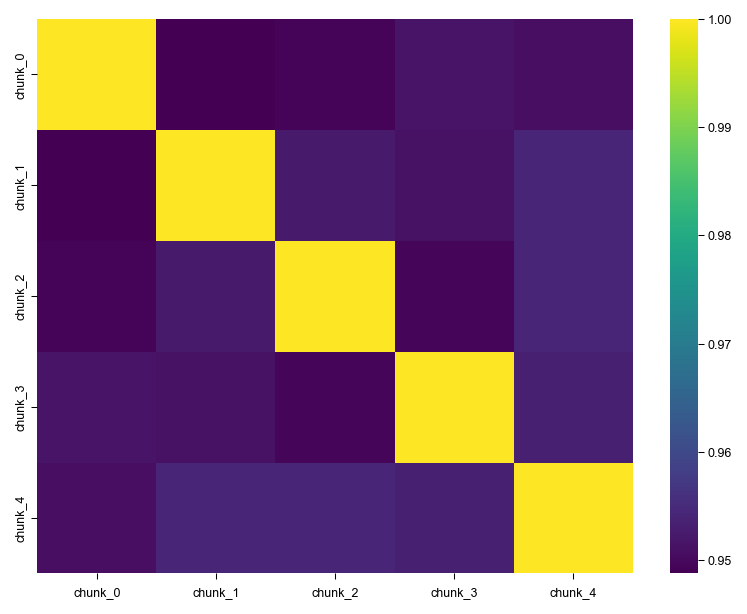

In [27]:
enriched_by_chunk = all_chunked_ensembles.pivot_table(
    index=['subject_name', 'task_stage', 'cell'], columns='chunk_index',values='enriched',aggfunc='first')

enriched_by_chunk.columns = [f'chunk_{i}' for i in enriched_by_chunk.columns]
chunk_col = [c for c in enriched_by_chunk.columns if 'chunk_' in c]
enriched_by_chunk=enriched_by_chunk.reset_index()
# Add summary columns
print(enriched_by_chunk.sample())
sns.heatmap(enriched_by_chunk[chunk_col].corr(), vmax = 1, cmap='viridis')   


#### import canon parquet, old and new Matlab TACOS


In [28]:
# import canonical ensemble matrix previously created in MATLAB, used for paper #find old file- 
canonical_file = data_dir / Path(r"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet")
canonical_data = pd.read_parquet(canonical_file)
print(canonical_data.info())

#get ensemble info from canon df
canon_ensembles  = canonical_data.groupby(by = ['unique_ID', 'geno', 'geno_day'])[stage_cols].first()
canon_ensembles.tail(3)

<class 'pandas.core.frame.DataFrame'>
Index: 93253 entries, 0 to 116376
Data columns (total 93 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   task_phase_vec     93253 non-null  object 
 1   IA_RS_vec          93253 non-null  object 
 2   corr_err_vec       93253 non-null  object 
 3   trial_num          93253 non-null  int64  
 4   neuron_ID          93253 non-null  int64  
 5   name               93253 non-null  object 
 6   day                93253 non-null  int32  
 7   geno               93253 non-null  object 
 8   geno_day           93253 non-null  object 
 9   -3.0s to -2.75s    93253 non-null  float64
 10  -2.75s to -2.5s    93253 non-null  float64
 11  -2.5s to -2.25s    93253 non-null  float64
 12  -2.25s to -2.0s    93253 non-null  float64
 13  -2.0s to -1.75s    93253 non-null  float64
 14  -1.75s to -1.5s    93253 non-null  float64
 15  -1.5s to -1.25s    93253 non-null  float64
 16  -1.25s to -1.0s    93253 n

,,,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
unique_ID,geno,geno_day,,,,,,
9_3_HET_RS3-97,HET,Het postCLNZ,1.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-98,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-99,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#original taco from 12/10/24 with 1k shuffles
canon_taco = data_dir / Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\main_datasets_complexTACO- neurons_activity by task phase_10-Dec-2024.xls")
canon_taco = pd.read_excel(canon_taco,na_values = -99).replace(-99, np.nan)

#get metadata
frame_cols = [c for c in canon_taco.columns if 'f_' in c]
non_frame_cols = [c for c in canon_taco.columns if 'f_' not in c]
post_stage_names = ['post_outcome_Early_IA_Error','post_outcome_Early_IA_Correct','post_outcome_Late_IA', 'post_outcome_Early_RS_Error', 'post_outcome_Early_RS_Correct','post_outcome_Late_RS']
print(non_frame_cols)
print(f" Unique canon cells: {canon_taco.groupby(by = 'name')['neuron_ID'].nunique().sum()}")
#get canon/original post taco
canon_post_taco = canon_taco[ post_stage_names +['name','geno_day','geno','neuron_ID']].copy()
canon_post_taco.rename({old:old.replace("post_outcome_","") for old in post_stage_names},axis=1, inplace=True)
canon_post_taco['unique_ID'] = canon_post_taco['name'].str.cat(canon_post_taco['neuron_ID'].astype(str), sep="-")
canon_post_taco

['pre_outcome_Early_IA_Error', 'pre_outcome_Early_IA_Correct', 'pre_outcome_Late_IA', 'pre_outcome_Early_RS_Error', 'pre_outcome_Early_RS_Correct', 'pre_outcome_Late_RS', 'post_outcome_Early_IA_Error', 'post_outcome_Early_IA_Correct', 'post_outcome_Late_IA', 'post_outcome_Early_RS_Error', 'post_outcome_Early_RS_Correct', 'post_outcome_Late_RS', 'ITI_Early_IA_Error', 'ITI_Early_IA_Correct', 'ITI_Late_IA', 'ITI_Early_RS_Error', 'ITI_Early_RS_Correct', 'ITI_Late_RS', 'baseline_sig_cells', 'name', 'geno_day', 'geno', 'neuron_ID', 'Var1_1', 'Var1_2', 'Var1_3', 'Var1_4', 'Var1_5', 'Var1_6']
 Unique canon cells: 5961


,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,name,geno_day,geno,neuron_ID,unique_ID
0,1.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,1,10_3_HET_RS1-1
1,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,2,10_3_HET_RS1-2
2,1.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,3,10_3_HET_RS1-3
3,0.0,0,0,1,0,0,10_3_HET_RS1,HET RS1,HET,4,10_3_HET_RS1-4
4,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,5,10_3_HET_RS1-5
...,...,...,...,...,...,...,...,...,...,...,...
5956,0.0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,211,9_3_HET_RS3-211
5957,1.0,1,0,0,0,0,9_3_HET_RS3,HET RS3,HET,212,9_3_HET_RS3-212
5958,0.0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,213,9_3_HET_RS3-213
5959,0.0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,214,9_3_HET_RS3-214


#### Compare MATLAB OLD vs MATLAB NEW enrichment vectors

In [29]:
#compare latest MATLAB TACO with old matlab TACO (used in papwer)
taco_old_new = new_taco_post.set_index('unique_ID').loc[:,stage_names].join(canon_post_taco.set_index('unique_ID'), how = 'inner', rsuffix = '_new')
taco_old_new

NameError: name 'new_taco_post' is not defined

In [ ]:
print(f"Newest MATLAB RUN algorithm: ensemble % enriched across all cells: \n{new_taco_post[stage_names].mean()}")
print(f"Old MATLAB base TACO algorithm: ensemble % enriched across all cells: \n{canon_post_taco[stage_names].mean()}")
##compare old vs new taco ensembles
df = taco_old_new
correlations = {stage: df[stage].corr(df[stage + '_new']) for stage in stage_names}
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(f" Correlation of enrichment vectors for OLD taco vs NEW run of TACO (same code): \n{corr_df}")

## Split-Half Reliability Test

Test: What correlation do we expect when running the SAME permutation method twice with different random seeds?

In [ ]:
# Split-half reliability test: Run Python method twice with different seed sets
print("SPLIT-HALF RELIABILITY TEST")
print("="*60)
print("Testing: Same algorithm, different RNG seeds")
print()

test_subject = "10_3_HET_RS1"
test_raster_df = raster_dataframes[test_subject]
cell_cols = [c for c in test_raster_df.columns if c.startswith("cell_")]

# Run 1: Seeds 1000-1999 (simulating "Run A")
print("Running shuffle set A (seeds 1000-1999)...")
shuffle_means_A = []
for seed in range(1000, 2000):
    rolled = random_roll_columns(test_raster_df[cell_cols].values, random_seed=seed)
    rolled_df = pd.DataFrame(rolled, columns=cell_cols, index=test_raster_df.index).join(
        test_raster_df.drop(columns=cell_cols)
    )
    mean_act = rolled_df[
        rolled_df["trial_section"] == "post_outcome"
    ].groupby("task_stage")[cell_cols].mean()
    shuffle_means_A.append(mean_act)

all_shuffles_A = pd.concat(shuffle_means_A, axis=0, keys=range(1000))

# Run 2: Seeds 2000-2999 (simulating "Run B")
print("Running shuffle set B (seeds 2000-2999)...")
shuffle_means_B = []
for seed in range(2000, 3000):
    rolled = random_roll_columns(test_raster_df[cell_cols].values, random_seed=seed)
    rolled_df = pd.DataFrame(rolled, columns=cell_cols, index=test_raster_df.index).join(
        test_raster_df.drop(columns=cell_cols)
    )
    mean_act = rolled_df[
        rolled_df["trial_section"] == "post_outcome"
    ].groupby("task_stage")[cell_cols].mean()
    shuffle_means_B.append(mean_act)

all_shuffles_B = pd.concat(shuffle_means_B, axis=0, keys=range(1000))

# Calculate 95th percentile thresholds for each run
print()
print("Calculating enrichment calls...")
thresholds_A = all_shuffles_A.groupby("task_stage")[cell_cols].agg(lambda x: np.percentile(x, 95))
thresholds_B = all_shuffles_B.groupby("task_stage")[cell_cols].agg(lambda x: np.percentile(x, 95))

# Get real activity
real_activity = test_raster_df[
    test_raster_df["trial_section"] == "post_outcome"
].groupby("task_stage")[cell_cols].mean()

# Determine enrichment for each run
enriched_A = (real_activity > thresholds_A).astype(int)
enriched_B = (real_activity > thresholds_B).astype(int)

print()
print("="*60)
print("RESULTS: Correlation between Run A and Run B")
print("="*60)

stages = ["Early_IA_Error", "Early_IA_Correct", "Late_IA", 
          "Early_RS_Error", "Early_RS_Correct", "Late_RS"]

print(f"{"Stage":<20} {"Correlation":<15} {"Agreement %":<15} {"Enriched A":<12} {"Enriched B":<12}")
print("-" * 75)

correlations = {}
for stage in stages:
    if stage in enriched_A.index:
        corr = enriched_A.loc[stage].corr(enriched_B.loc[stage])
        agreement = (enriched_A.loc[stage] == enriched_B.loc[stage]).mean()
        rate_A = enriched_A.loc[stage].mean()
        rate_B = enriched_B.loc[stage].mean()
        
        correlations[stage] = corr
        print(f"{stage:<20} {corr:<15.3f} {agreement:<15.1%} {rate_A:<12.1%} {rate_B:<12.1%}")

print()
print(f"Mean correlation across stages: {np.mean(list(correlations.values())):.3f}")
print()
print("INTERPRETATION:")
print("This correlation represents the EXPECTED agreement when using")
print("the same method twice with different random seeds.")
print("Your Python vs MATLAB correlation should be compared to this baseline.")